# Project 4: Data Visualization & Visual Storytelling

## Introduction

Data visualization is the process of representing data using
graphs and charts so that patterns, comparisons, and trends can
be understood easily.

This project focuses on creating meaningful visualizations from
an e-commerce dataset using Python, Pandas, and Matplotlib.

Unlike exploratory data analysis, the main focus of this project
is on selecting suitable visualizations, improving chart
readability, presenting information clearly, and communicating
business findings through visual storytelling.

The project demonstrates how raw analytical results can be
converted into clear visual information for decision-making.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("project1_final.xlsx")

In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,Cleaned_coupon,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
df.shape

(1200, 14)

In [6]:
df.describe

<bound method NDFrame.describe of         OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card 

## 1. Data Preparation

The Date column is converted into datetime format so that
time-based visualizations can be created correctly.

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

## 2. Choosing Appropriate Visualizations

Different charts are useful for different purposes:

- Bar charts are useful for comparing categories.
- Line charts are useful for showing trends over time.
- Histograms are useful for showing distributions.
- Pie charts can be used to show simple proportions.

Selecting the appropriate chart makes the information easier
for the viewer to understand.

## 3. Product Order Comparison

A bar chart is used to compare the number of orders across
different product categories.

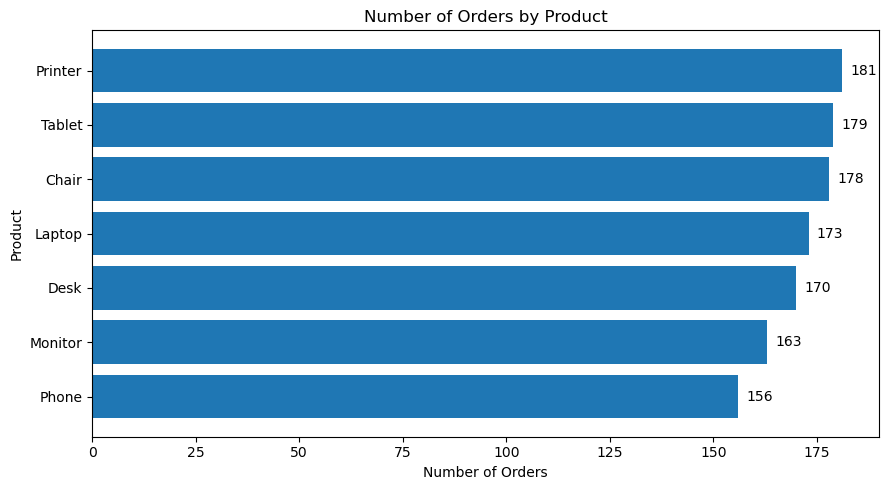

In [8]:
product_orders = df['Product'].value_counts().sort_values()

plt.figure(figsize=(9,5))

bars = plt.barh(product_orders.index, product_orders.values)

plt.title('Number of Orders by Product')
plt.xlabel('Number of Orders')
plt.ylabel('Product')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 2,
             bar.get_y() + bar.get_height()/2,
             str(int(width)),
             va='center')

plt.tight_layout()
plt.show()

### Interpretation

The bar chart compares order volume across the different
products. The product with the longest bar has the highest
number of orders.

Data labels make the exact values easier to read and compare.

## 4. Sales by Product

A horizontal bar chart is used to compare the total sales
generated by different products.

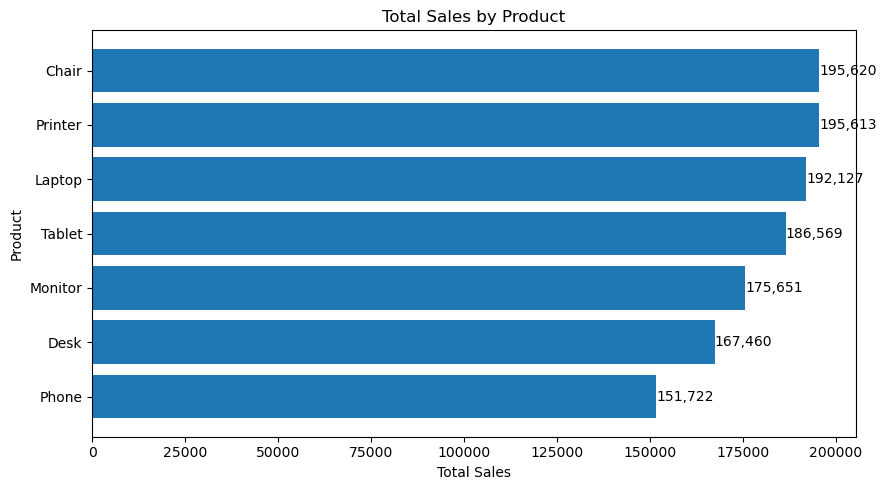

In [9]:
product_sales = (
    df.groupby('Product')['TotalPrice']
    .sum()
    .sort_values()
)

plt.figure(figsize=(9,5))

bars = plt.barh(product_sales.index, product_sales.values)

plt.title('Total Sales by Product')
plt.xlabel('Total Sales')
plt.ylabel('Product')

for bar in bars:
    width = bar.get_width()
    plt.text(width,
             bar.get_y() + bar.get_height()/2,
             f'{width:,.0f}',
             va='center')

plt.tight_layout()
plt.show()


In [10]:
plt.savefig(
    'product_sales.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

### Interpretation

The visualization compares the revenue contribution of each
product category. Products with larger bars contribute more
to total sales.

## 5. Monthly Sales Trend

A line chart is used to visualize changes in sales over time.

In [14]:
monthly_sales = (
    df.groupby(df['Date'].dt.to_period('M'))['TotalPrice']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

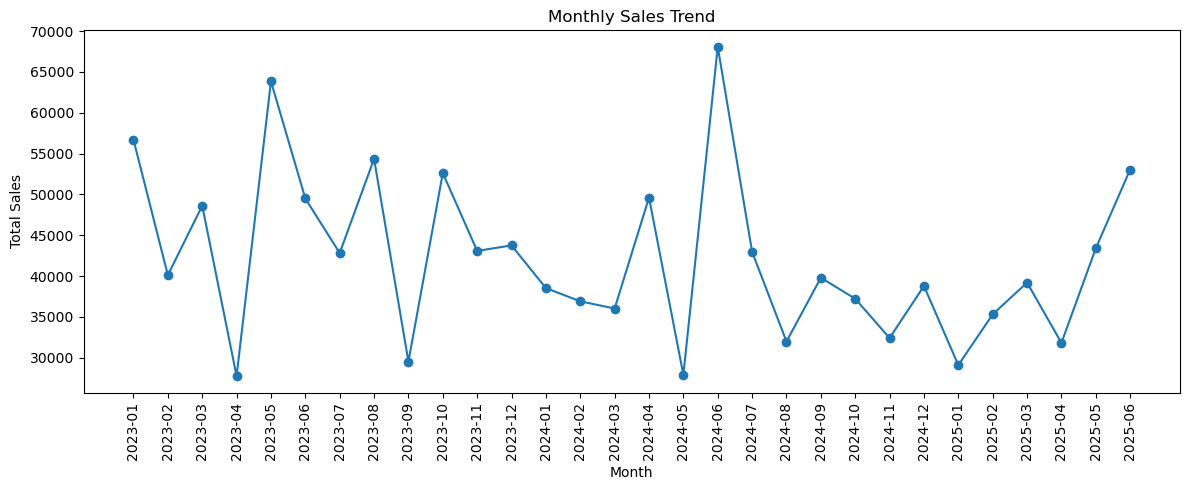

In [15]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Interpretation

The line chart shows how sales changed over the available
months. Higher points represent periods with relatively
higher sales, while lower points represent periods with
lower sales.

In [16]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

print("Highest Sales Month:", highest_month)
print("Sales:", highest_sales)

Highest Sales Month: 2024-06
Sales: 68068.54000000001


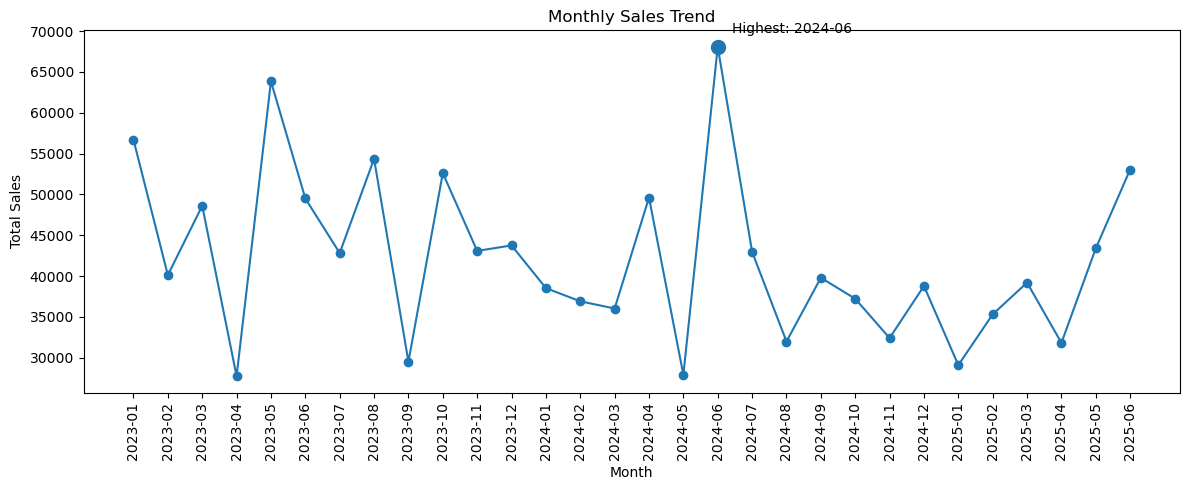

In [17]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.scatter(
    highest_month,
    highest_sales,
    s=100
)

plt.annotate(
    f'Highest: {highest_month}',
    xy=(highest_month, highest_sales),
    xytext=(10,10),
    textcoords='offset points'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Visual Story

The highest-sales period is highlighted to draw attention to
an important point in the sales trend.

Highlighting important observations helps communicate the
main message of a visualization more effectively.

## 6. Order Value Distribution

A histogram is used to show how transaction values are
distributed across different ranges.



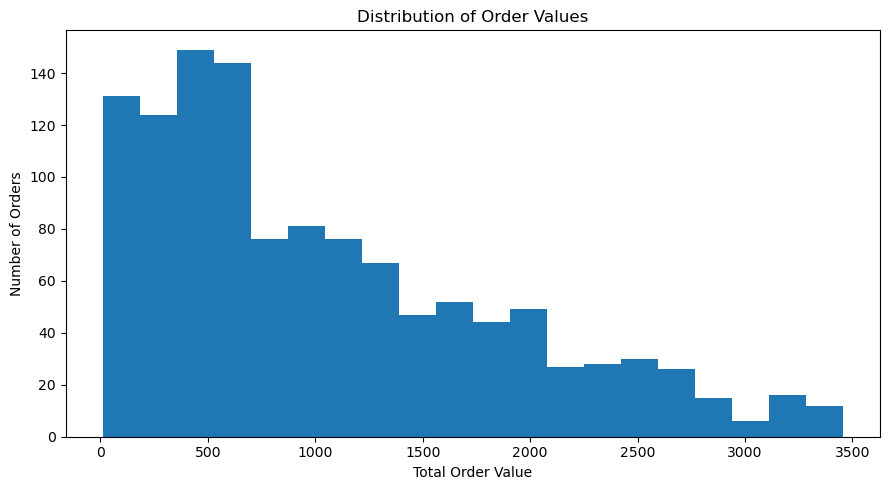

In [19]:
plt.figure(figsize=(9,5))

plt.hist(df['TotalPrice'], bins=20)

plt.title('Distribution of Order Values')
plt.xlabel('Total Order Value')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

### Interpretation

The histogram shows how frequently different order-value
ranges occur. It helps provide a visual understanding of
the typical transaction values in the dataset.

## 7. Payment Method Distribution

A pie chart is used to show the proportion of orders made
through different payment methods.

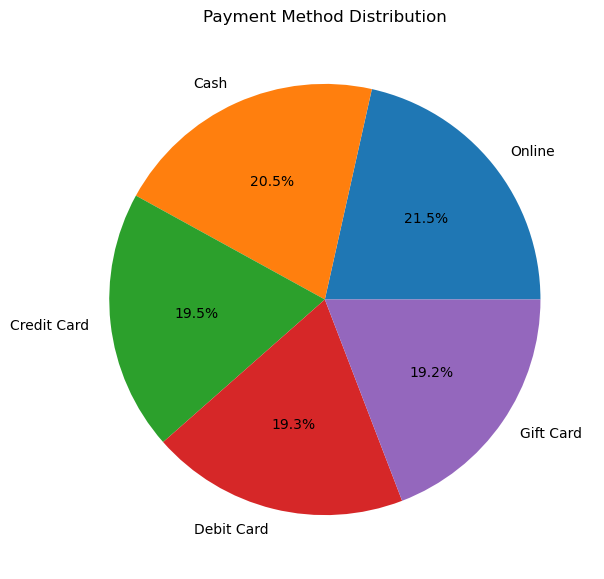

In [20]:
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Payment Method Distribution')
plt.show()

### Interpretation

The pie chart shows the percentage share of each payment
method. It provides a quick visual overview of customer
payment preferences.

## 8. Yearly Sales Comparison

A bar chart is used to compare overall sales across the
available years.

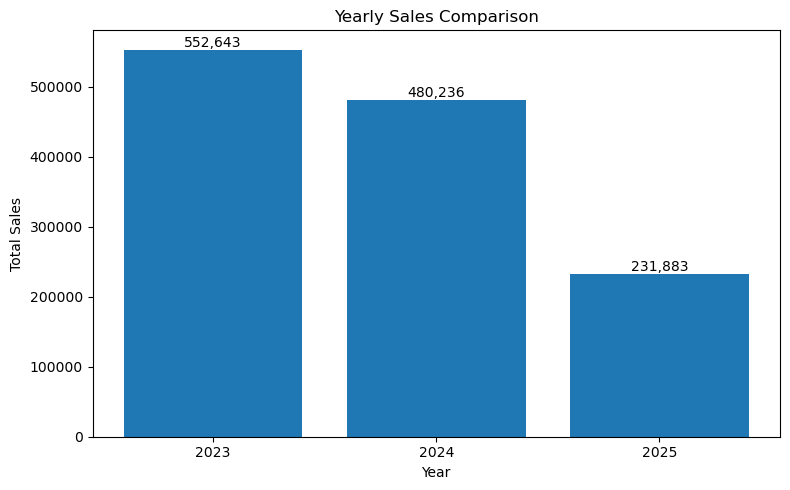

In [21]:
yearly_sales = (
    df.groupby(df['Date'].dt.year)['TotalPrice']
    .sum()
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    yearly_sales.index.astype(str),
    yearly_sales.values
)

plt.title('Yearly Sales Comparison')
plt.xlabel('Year')
plt.ylabel('Total Sales')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Interpretation

The chart compares total sales across the available years.
It provides a simple visual representation of changes in
overall sales performance.

# 9. Visual Storytelling

The visualizations created in this project communicate several
aspects of the e-commerce business.

The product order chart shows differences in customer demand,
while the product sales chart shows differences in revenue
contribution.

The monthly sales chart communicates how sales change over
time and helps identify important periods.

The order-value histogram shows the distribution of transaction
values, while the payment-method chart communicates customer
payment preferences.

The yearly sales comparison provides an overall view of sales
performance across the available years.

Together, these visualizations transform numerical information
into an understandable visual story.

# 10. Key Visual Insights

Based on the visualizations:

1. Product order volumes differ across the available product
   categories.

2. Product sales vary, with some products contributing more
   revenue than others.

3. Monthly sales show variations across the available period,
   with certain months recording higher activity.

4. The payment-method visualization shows differences in
   customer preferences.

5. The order-value histogram shows the distribution of
   transaction values.

6. Yearly sales provide an overall comparison of business
   performance across the available years.

7. Visualizations make important patterns easier to identify
   than viewing raw numerical data alone.

# 11. Recommendations

Based on the visual analysis:

- Monitor products with high order demand.
- Maintain suitable inventory for frequently purchased products.
- Study products contributing strongly to sales.
- Examine periods of unusually high or low sales.
- Continue supporting commonly used payment methods.
- Use visual reports to communicate important business metrics.
- Regularly update visualizations to monitor changes in sales
  performance.

# 12. Conclusion

This project provided practical experience in data visualization
and visual storytelling using Python, Pandas, and Matplotlib.

Bar charts, line charts, histograms, and pie charts were used
to communicate different types of information from the
e-commerce dataset.

The project demonstrated that selecting the appropriate chart,
adding clear labels, highlighting important observations, and
organizing visualizations into a logical story can make data
easier to understand.

The visual analysis can support business decisions related to
sales, products, inventory, and customer preferences.

In [22]:
plt.savefig(
    'product_sales.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [23]:
plt.savefig(
    'monthly_sales.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>